In [1]:
%cd ..

/home/dev/workspace


In [2]:
import hydra
import jax.numpy as jnp
import numpyro
import matplotlib.pyplot as plt

In [3]:
from src.model import model

In [4]:
with hydra.initialize(version_base="1.3", config_path="../configs/", job_name="eval"):
    cfg = hydra.compose(config_name="model/captcha_generator.yaml", return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    captcha_model = hydra.utils.instantiate(cfg.model)

/home/dev/workspace/.venv/lib/python3.13/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'model/captcha_generator.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
E0710 18:41:00.245779  312733 ptx_compiler_helpers.cc:157] *** WARNING *** Invoking ptxas with version 12.4.131, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


In [5]:
# captcha_model.keywords["placements"].prior.u_init.shape

In [6]:
# jnp.exp(captcha_model.keywords["placements"].prior.u_init).sum()

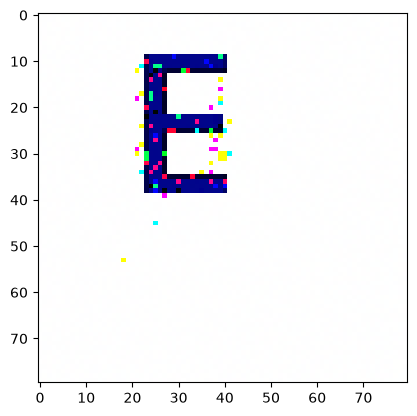

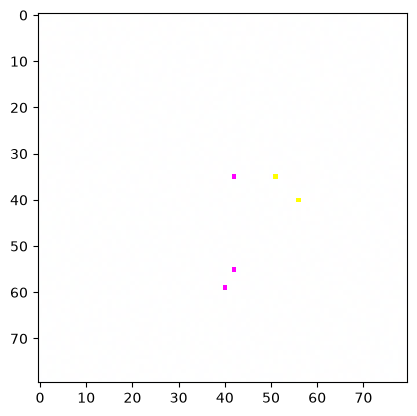

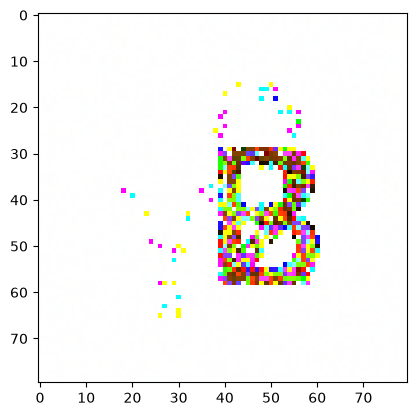

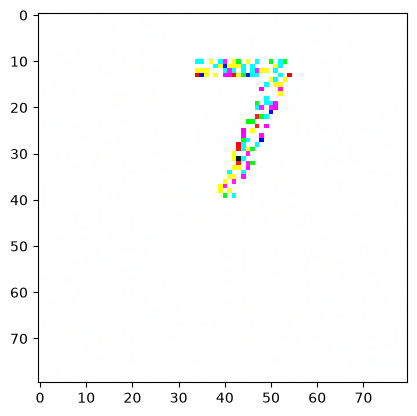

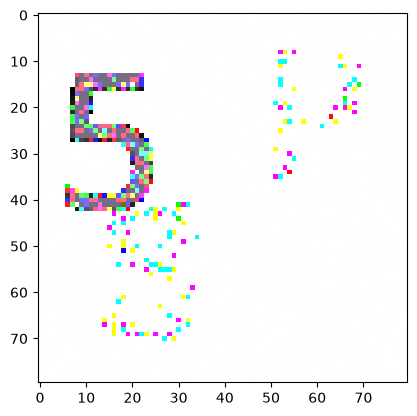

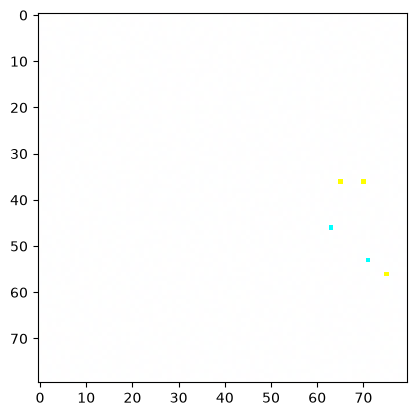

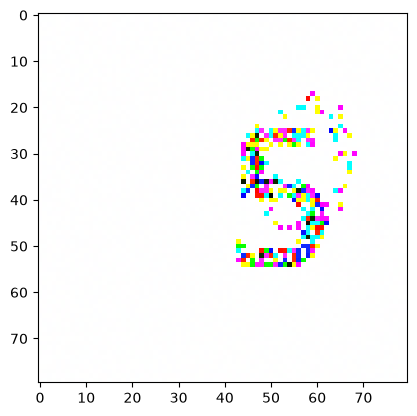

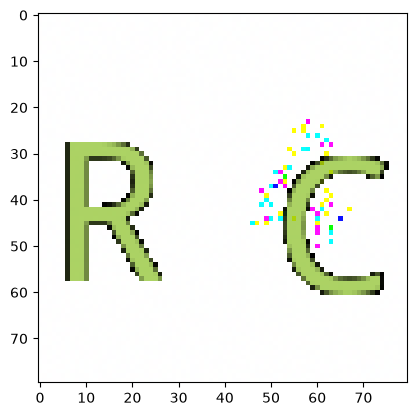

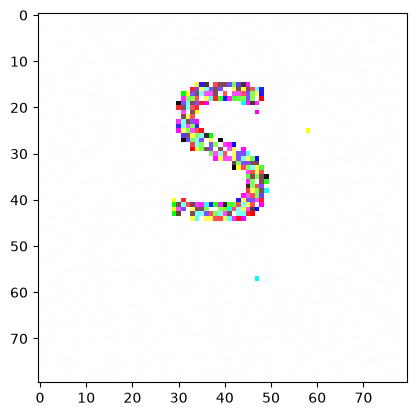

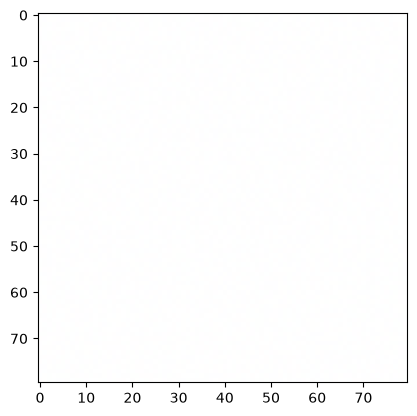

In [10]:
for i in range(10):
    with numpyro.handlers.seed(rng_seed=i):
        imgs = captcha_model(None, scale=1e-3)
        imgs = jnp.clip(imgs, 0., 1.)

    plt.imshow(jnp.moveaxis(imgs[0].squeeze(), 0, -1), vmin=0., vmax=1.)
    plt.show()